In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

BASE_DIR      = Path(os.getcwd())
FILTERED_DIR  = BASE_DIR / "brd4_pipeline" / "data" / "filtered"
PROCESSED_DIR = BASE_DIR / "brd4_pipeline" / "data" / "processed"
OUTPUTS_DIR   = BASE_DIR / "brd4_pipeline" / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROCESSED_DIR / "brd4_best_model.pkl", 'rb') as f:
    model = pickle.load(f)

with open(PROCESSED_DIR / "brd4_model_meta.json", 'r') as f:
    model_meta = json.load(f)

with open(PROCESSED_DIR / "brd4_ad_params.json", 'r') as f:
    ad_params = json.load(f)

print(f"[INFO] Model loaded        : {model_meta['best_model_name']}")
print(f"[INFO] Training Test R²    : {model_meta['test_r2']}")
print(f"[INFO] Training Test RMSE  : {model_meta['test_rmse']}")
print(f"[INFO] AD parameters loaded: PC1 [{ad_params['pc1_lower']:.2f}, {ad_params['pc1_upper']:.2f}]")
print(f"                             PC2 [{ad_params['pc2_lower']:.2f}, {ad_params['pc2_upper']:.2f}]")

[INFO] Model loaded        : Random Forest (tuned)
[INFO] Training Test R²    : 0.7148
[INFO] Training Test RMSE  : 0.6484
[INFO] AD parameters loaded: PC1 [-17.66, 17.66]
                             PC2 [-15.42, 15.42]


In [2]:
from chembl_webresource_client.new_client import new_client

print("[INFO] Downloading ChEMBL approved drugs library...")
print("[INFO] This may take 60-120 seconds.")

molecule = new_client.molecule

results = molecule.filter(
    max_phase=4,
    molecule_type='Small molecule'
).only(
    'molecule_chembl_id',
    'pref_name',
    'molecule_structures'
)

results_list = list(results)
print(f"[INFO] Downloaded {len(results_list):,} approved drugs.")

records = []
for r in results_list:
    try:
        smiles = r['molecule_structures']['canonical_smiles']
        if smiles:
            records.append({
                'molecule_chembl_id' : r['molecule_chembl_id'],
                'drug_name'          : r.get('pref_name', 'Unknown'),
                'canonical_smiles'   : smiles
            })
    except (TypeError, KeyError):
        continue

df_library = pd.DataFrame(records)
print(f"[INFO] Compounds with valid SMILES: {len(df_library):,}")

library_file = PROCESSED_DIR / "screening_library_raw.csv"
df_library.to_csv(library_file, index=False)
print(f"[SAVED] {library_file}")

[INFO] Downloading ChEMBL approved drugs library...
[INFO] This may take 60-120 seconds.
[INFO] Downloaded 3,475 approved drugs.
[INFO] Compounds with valid SMILES: 3,311
[SAVED] C:\Users\raksh\brd4_pipeline\data\processed\screening_library_raw.csv


In [4]:
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit import RDLogger
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

RDLogger.DisableLog('rdApp.*')
remover = SaltRemover()

def standardize_smiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return None
    try:
        mol = remover.StripMol(mol, dontRemoveEverything=True)
    except Exception:
        pass
    if mol is None or mol.GetNumAtoms() == 0:
        return None
    return Chem.MolToSmiles(mol, isomericSmiles=True)

def calculate_properties(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return pd.Series({
            'MW': np.nan, 'LogP': np.nan,
            'HBD': np.nan, 'HBA': np.nan,
            'TPSA': np.nan, 'RotB': np.nan
        })
    return pd.Series({
        'MW'   : Descriptors.MolWt(mol),
        'LogP' : Descriptors.MolLogP(mol),
        'HBD'  : rdMolDescriptors.CalcNumHBD(mol),
        'HBA'  : rdMolDescriptors.CalcNumHBA(mol),
        'TPSA' : Descriptors.TPSA(mol),
        'RotB' : rdMolDescriptors.CalcNumRotatableBonds(mol)
    })

print("[INFO] Standardizing library structures...")
df_library['smiles_clean'] = df_library['canonical_smiles'].apply(standardize_smiles)

before = len(df_library)
df_library = df_library.dropna(subset=['smiles_clean'])
df_library = df_library.drop_duplicates(subset='smiles_clean')
after = len(df_library)
print(f"After cleaning: {before:,} → {after:,} compounds")

print("[INFO] Calculating properties...")
props = df_library['smiles_clean'].apply(calculate_properties)
df_library[['MW','LogP','HBD','HBA','TPSA','RotB']] = props

before = len(df_library)
df_library = df_library.dropna(subset=['MW','LogP','HBD','HBA','TPSA','RotB'])

druglike = (
    (df_library['MW']   <= 500) &
    (df_library['LogP'] <= 5)   &
    (df_library['HBD']  <= 5)   &
    (df_library['HBA']  <= 10)  &
    (df_library['RotB'] <= 10)  &
    (df_library['TPSA'] <= 140)
)
df_library = df_library[druglike].copy()
after = len(df_library)
print(f"After drug-likeness filter: {before:,} → {after:,} compounds")

params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_A)
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_B)
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS_C)
catalog = FilterCatalog(params)

def is_pains(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return True
    return catalog.HasMatch(mol)

before = len(df_library)
df_library['is_pains'] = df_library['smiles_clean'].apply(is_pains)
df_library = df_library[~df_library['is_pains']].copy()
after = len(df_library)
print(f"After PAINS filter: {before:,} → {after:,} compounds")
print(f"\n[INFO] Clean screening library: {len(df_library):,} compounds ready.")

[INFO] Standardizing library structures...
After cleaning: 3,311 → 2,618 compounds
[INFO] Calculating properties...
After drug-likeness filter: 2,618 → 1,688 compounds
After PAINS filter: 1,688 → 1,614 compounds

[INFO] Clean screening library: 1,614 compounds ready.


In [6]:
from rdkit.Chem import AllChem

def morgan_fingerprint(smiles, radius=2, nBits=2048):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(nBits, dtype=int)
    fp=AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
    return np.array(fp)

print(f"[INFO] Generating Morgan Fingerprint for screening library...")
library_fps=np.array([morgan_fingerprint(smi) for smi in df_library['smiles_clean']])
print(f"[DONE] Fingerprint matrix : {library_fps.shape}")

print(f"[INFO] Running QSAR predictions....")
df_library['predicted_pIC50']=model.predict(library_fps)
print(f"[DONE] Predictions complete...")
print(f"\nPredicted pIC50 statistics:")
print(df_library['predicted_pIC50'].describe().round(3))

[INFO] Generating Morgan Fingerprint for screening library...
[DONE] Fingerprint matrix : (1614, 2048)
[INFO] Running QSAR predictions....
[DONE] Predictions complete...

Predicted pIC50 statistics:
count    1614.000
mean        6.174
std         0.337
min         4.435
25%         5.986
50%         6.147
75%         6.363
max         7.955
Name: predicted_pIC50, dtype: float64


In [9]:
from rdkit.Chem import RDConfig
import sys

sa_path = os.path.join(RDConfig.RDContribDir, 'SA_Score')
if sa_path not in sys.path:
    sys.path.append(sa_path)

try:
    import sascorer
    print("[INFO] SA Score module loaded successfully.")
    use_sa = True
except ImportError:
    print("[WARNING] SA Score module not found.")
    print("[INFO] Skipping SA Score — will filter by predicted pIC50 only.")
    use_sa = False

def calculate_sa_score(smiles):
    if not use_sa:
        return np.nan
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return np.nan
    try:
        return sascorer.calculateScore(mol)
    except Exception:
        return np.nan

if use_sa:
    print("[INFO] Calculating SA Scores...")
    df_library['sa_score'] = df_library['smiles_clean'].apply(calculate_sa_score)
    print(f"SA Score statistics:")
    print(df_library['sa_score'].describe().round(2))
else:
    df_library['sa_score'] = np.nan

[INFO] SA Score module loaded successfully.
[INFO] Calculating SA Scores...
SA Score statistics:
count    1614.00
mean        3.17
std         1.13
min         1.11
25%         2.39
50%         2.95
75%         3.70
max         8.48
Name: sa_score, dtype: float64


In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("[INFO] Checking Applicability Domain for library compounds...")

training_fps = np.load(PROCESSED_DIR / "brd4_morgan_fp.npy")

scaler_ad  = StandardScaler()
pca_ad     = PCA(n_components=2, random_state=42)

training_scaled = scaler_ad.fit_transform(training_fps)
pca_ad.fit(training_scaled)

library_scaled  = scaler_ad.transform(library_fps)
library_pca     = pca_ad.transform(library_scaled)

inside_ad = (
    (library_pca[:, 0] >= ad_params['pc1_lower']) &
    (library_pca[:, 0] <= ad_params['pc1_upper']) &
    (library_pca[:, 1] >= ad_params['pc2_lower']) &
    (library_pca[:, 1] <= ad_params['pc2_upper'])
)

df_library['inside_ad']  = inside_ad
df_library['pca_dim1']   = library_pca[:, 0]
df_library['pca_dim2']   = library_pca[:, 1]

n_inside  = inside_ad.sum()
n_outside = (~inside_ad).sum()
print(f"Inside AD  : {n_inside:,} ({n_inside/len(df_library)*100:.1f}%)")
print(f"Outside AD : {n_outside:,} ({n_outside/len(df_library)*100:.1f}%)")

[INFO] Checking Applicability Domain for library compounds...
Inside AD  : 1,614 (100.0%)
Outside AD : 0 (0.0%)


In [11]:
print("[INFO] Applying hit filters and ranking...")

df_hits = df_library.copy()
before  = len(df_hits)

df_hits = df_hits[df_hits['predicted_pIC50'] >= 6.0]
print(f"After pIC50 ≥ 6.0 filter : {before:,} → {len(df_hits):,}")

before = len(df_hits)
df_hits = df_hits[df_hits['inside_ad'] == True]
print(f"After AD filter  : {before:,} → {len(df_hits):,}")

if use_sa:
    before = len(df_hits)
    df_hits = df_hits[
        df_hits['sa_score'].isna() |
        (df_hits['sa_score'] <= 6.0)
    ]
    print(f"After SA Score ≤ 6.0     : {before:,} → {len(df_hits):,}")

df_hits = df_hits.sort_values('predicted_pIC50', ascending=False)
df_hits = df_hits.reset_index(drop=True)

print(f"\n{'='*55}")
print(f"  FINAL HIT LIST: {len(df_hits):,} compounds")
print(f"{'='*55}")

display_cols = ['molecule_chembl_id', 'drug_name', 'predicted_pIC50', 'MW', 'LogP', 'inside_ad']
if use_sa:
    display_cols.append('sa_score')

print("\nTop 10 predicted BRD4 inhibitors from approved drugs:")
print(df_hits[display_cols].head(10).to_string(index=False))

[INFO] Applying hit filters and ranking...
After pIC50 ≥ 6.0 filter : 1,614 → 1,186
After AD filter  : 1,186 → 1,186
After SA Score ≤ 6.0     : 1,186 → 1,153

  FINAL HIT LIST: 1,153 compounds

Top 10 predicted BRD4 inhibitors from approved drugs:
molecule_chembl_id                      drug_name  predicted_pIC50      MW    LogP  inside_ad  sa_score
         CHEMBL535                      SUNITINIB         7.954754 398.482 3.33494       True  2.647147
         CHEMBL411             DIETHYLSTILBESTROL         7.474707 268.356 4.82860       True  2.139420
     CHEMBL1200598 DIETHYLSTILBESTROL DIPHOSPHATE         7.465926 428.314 4.36040       True  2.698879
     CHEMBL1094636                      NIRAPARIB         7.296740 320.396 2.59140       True  2.844508
         CHEMBL430                   GEMIFLOXACIN         7.293142 389.387 0.96600       True  3.556039
     CHEMBL3655081                    ABROCITINIB         7.258035 323.422 1.25450       True  2.942142
     CHEMBL1779710      

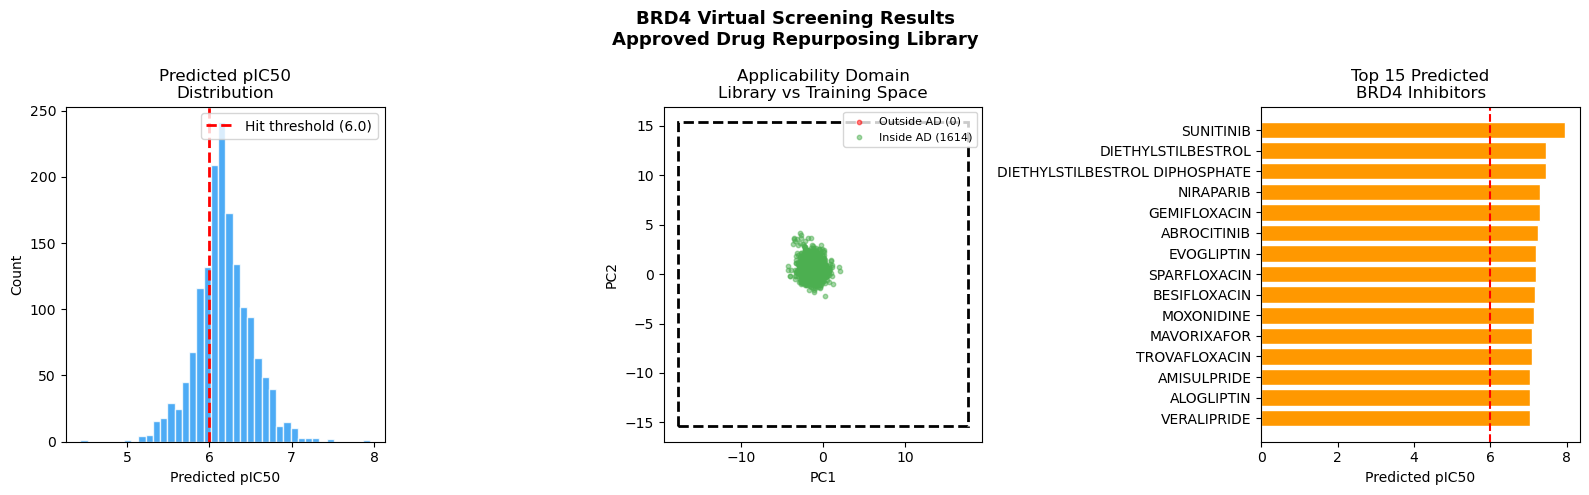

[SAVED] Virtual screening plot saved.


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('BRD4 Virtual Screening Results\nApproved Drug Repurposing Library',fontsize=13, fontweight='bold')

axes[0].hist(df_library['predicted_pIC50'], bins=40,
             color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(x=6.0, color='red', linestyle='--',
                linewidth=2, label='Hit threshold (6.0)')
axes[0].set_xlabel('Predicted pIC50')
axes[0].set_ylabel('Count')
axes[0].set_title('Predicted pIC50\nDistribution')
axes[0].legend()

axes[1].scatter(library_pca[~inside_ad, 0],
                library_pca[~inside_ad, 1],
                c='red', s=10, alpha=0.5,
                label=f'Outside AD ({(~inside_ad).sum()})')
axes[1].scatter(library_pca[inside_ad, 0],
                library_pca[inside_ad, 1],
                c='#4CAF50', s=10, alpha=0.5,
                label=f'Inside AD ({inside_ad.sum()})')

from matplotlib.patches import Rectangle
rect = Rectangle(
    (ad_params['pc1_lower'], ad_params['pc2_lower']),
    ad_params['pc1_upper'] - ad_params['pc1_lower'],
    ad_params['pc2_upper'] - ad_params['pc2_lower'],
    linewidth=2, edgecolor='black',
    facecolor='none', linestyle='--'
)
axes[1].add_patch(rect)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Applicability Domain\nLibrary vs Training Space')
axes[1].legend(fontsize=8)

top15 = df_hits.head(15)
bars  = axes[2].barh(
    top15['drug_name'].fillna(top15['molecule_chembl_id']),
    top15['predicted_pIC50'],
    color='#FF9800', edgecolor='white'
)
axes[2].axvline(x=6.0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Predicted pIC50')
axes[2].set_title('Top 15 Predicted\nBRD4 Inhibitors')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "module06_virtual_screening.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] Virtual screening plot saved.")

In [13]:
hits_file = FILTERED_DIR / "brd4_virtual_hits.csv"
df_hits.to_csv(hits_file, index=False)
print(f"[SAVED] {hits_file}")

full_file = FILTERED_DIR / "brd4_screened_library.csv"
df_library.to_csv(full_file, index=False)
print(f"[SAVED] {full_file}")

print("=" * 55)
print("  MODULE 6 — PIPELINE AUDIT REPORT")
print("  Target: BRD4 (CHEMBL4523)")
print("=" * 55)
print(f"  Model used              : {model_meta['best_model_name']}")
print(f"  Model Test R²           : {model_meta['test_r2']}")
print()
print(f"  Screening library:")
print(f"    Raw approved drugs    : {len(results_list):,}")
print(f"    After cleaning        : {len(df_library):,}")
print()
print(f"  Predictions:")
print(f"    Predicted pIC50 mean  : {df_library['predicted_pIC50'].mean():.2f}")
print(f"    Predicted pIC50 max   : {df_library['predicted_pIC50'].max():.2f}")
print()
print(f"  Filters applied:")
print(f"    pIC50 ≥ 6.0           : required")
print(f"    Inside AD             : required")
if use_sa:
    print(f"    SA Score ≤ 6.0        : required")
print()
print(f"  Final hit count         : {len(df_hits):,}")
print()
print(f"  Top 5 hits:")
for i, row in df_hits.head(5).iterrows():
    name = row['drug_name'] if pd.notna(row['drug_name']) else row['molecule_chembl_id']
    print(f"    {i+1}. {name:<25} pIC50={row['predicted_pIC50']:.2f}")
print()
print("  Files saved:")
print("  filtered/  brd4_virtual_hits.csv")
print("  filtered/  brd4_screened_library.csv")
print("  outputs/   module06_virtual_screening.png")
print("=" * 55)
print("  Module 6 complete.")
print("=" * 55)

[SAVED] C:\Users\raksh\brd4_pipeline\data\filtered\brd4_virtual_hits.csv
[SAVED] C:\Users\raksh\brd4_pipeline\data\filtered\brd4_screened_library.csv
  MODULE 6 — PIPELINE AUDIT REPORT
  Target: BRD4 (CHEMBL4523)
  Model used              : Random Forest (tuned)
  Model Test R²           : 0.7148

  Screening library:
    Raw approved drugs    : 3,475
    After cleaning        : 1,614

  Predictions:
    Predicted pIC50 mean  : 6.17
    Predicted pIC50 max   : 7.95

  Filters applied:
    pIC50 ≥ 6.0           : required
    Inside AD             : required
    SA Score ≤ 6.0        : required

  Final hit count         : 1,153

  Top 5 hits:
    1. SUNITINIB                 pIC50=7.95
    2. DIETHYLSTILBESTROL        pIC50=7.47
    3. DIETHYLSTILBESTROL DIPHOSPHATE pIC50=7.47
    4. NIRAPARIB                 pIC50=7.30
    5. GEMIFLOXACIN              pIC50=7.29

  Files saved:
  filtered/  brd4_virtual_hits.csv
  filtered/  brd4_screened_library.csv
  outputs/   module06_virtual_scre